### Example accessing the model with Lat/Lon and plotting a map view

In [ ]:
#%load_ext autoreload
#%autoreload 2

from ocean_model_interfaces import GeodeticGridParameters, GeodeticGrid, CoordinateType
import numpy as np
import matplotlib.pyplot as plt
from auv_utility import position_util as position_util

parameters = GeodeticGridParameters("/Users/branch/projs/ocean_worlds/misc_data/models/regularized_vailuluu_plume_24hr_set1/", depthChunkSize=35, latChunkSize=500, lonChunkSize=500)

model = GeodeticGrid(parameters)
model.set_coordinate_type(CoordinateType.LATLON)
time = 2510816.0
depth = -600

num_lats = 835
num_lons = 555
lats = np.linspace(-14.576293545209538, -13.86710987174015, num_lats)
lons = np.linspace(-169.2593537414966, -168.78826530612244, num_lons)

data = np.empty((num_lats,num_lons))
data[:] = np.nan

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        
        model_data = model.get_data(lon, lat, depth, time)
        data[i,j] = model_data["dye"]

-14.576293545209538 -13.86710987174015
-169.2593537414966 -168.78826530612244


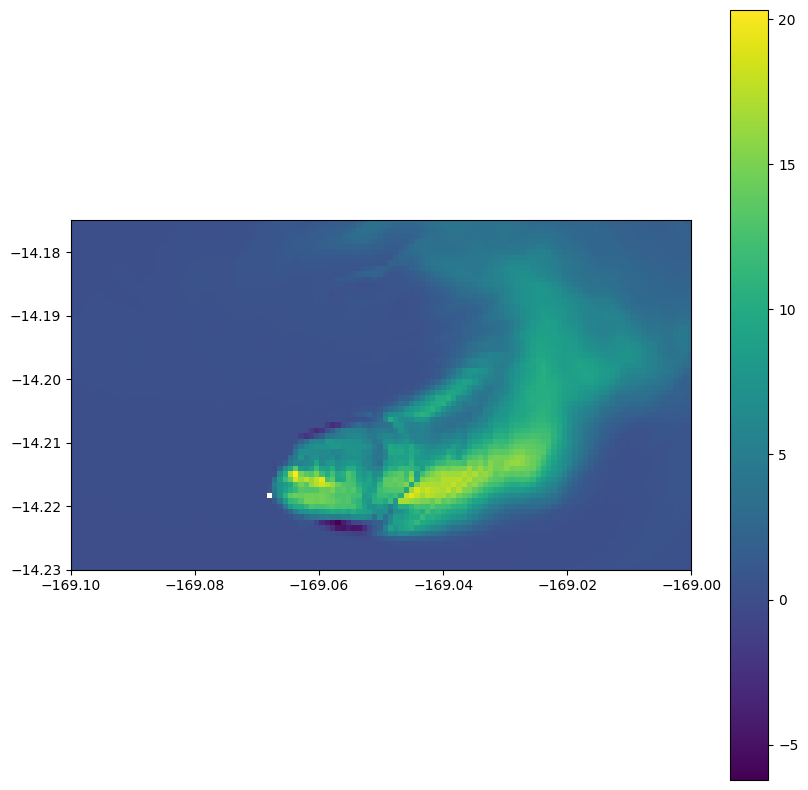

In [2]:
plt.figure(figsize=(10, 10))
c = plt.gca().pcolormesh(lons, lats, data, shading="nearest")
print(lats.min(), lats.max())
print(lons.min(), lons.max())

plt.colorbar(c)

center_lat = (lats.min() + lats.max()) / 2
center_lon = (lons.min() + lons.max()) / 2

mdeglat = position_util.alvin_xy_mdeglat(center_lat)
mdeglon = position_util.alvin_xy_mdeglon(center_lat)


plt.gca().set_ylim([-14.23, -14.175])
plt.gca().set_xlim([-169.1, -169.0])

plt.gca().set_aspect(mdeglat/mdeglon, adjustable='box')

plt.show()

### Example plotting a side view

In [ ]:
#%load_ext autoreload
#%autoreload 2

from ocean_model_interfaces import GeodeticGridParameters, GeodeticGrid, CoordinateType
import numpy as np
import matplotlib.pyplot as plt
from auv_utility import position_util as position_util

parameters = GeodeticGridParameters("/Users/branch/projs/ocean_worlds/misc_data/models/regularized_vailuluu_plume_24hr_set1/", depthChunkSize=35, latChunkSize=500, lonChunkSize=500)

model = GeodeticGrid(parameters)
model.set_coordinate_type(CoordinateType.LATLON)

time = 2510816.0
lat = -14.215

num_depths = 150
num_lons = 555

depths = np.linspace(0, -1000, num_depths)
lons = np.linspace(-169.2593537414966, -168.78826530612244, num_lons)

data = np.empty((num_depths,num_lons))
data[:] = np.nan

for i, depth in enumerate(depths):
    for j, lon in enumerate(lons):
        
        model_data = model.get_data(lon, lat, depth, time)
        data[i,j] = model_data["dye"]

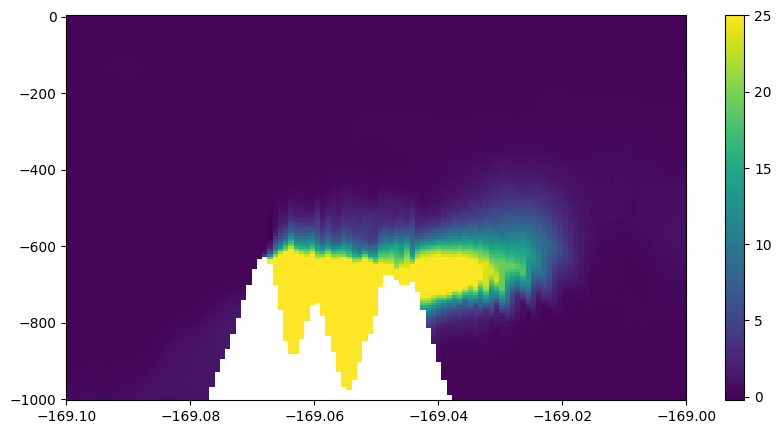

In [7]:
import matplotlib

plt.figure(figsize=(10, 5))
c = plt.gca().pcolormesh(lons, depths, data, vmax=25)
plt.colorbar(c)
plt.gca().set_xlim([-169.1, -169.0])

plt.show()

### Example plotting along a transect

In [8]:
#%load_ext autoreload
#%autoreload 2

from ocean_model_interfaces import GeodeticGridParameters, GeodeticGrid, CoordinateType
import numpy as np
import matplotlib.pyplot as plt
from auv_utility import position_util as position_util

parameters = GeodeticGridParameters("/Users/branch/projs/ocean_worlds/misc_data/models/regularized_vailuluu_plume_24hr_set1/", depthChunkSize=35, latChunkSize=500, lonChunkSize=500)

model = GeodeticGrid(parameters)
model.set_coordinate_type(CoordinateType.LATLON)

time = 2510816.0
lat = -14.215
depth = -600
num_lons = 10000

lons = np.linspace(-169.2593537414966, -168.78826530612244, num_lons)

data = []
for j, lon in enumerate(lons):
    model_data = model.get_data(lon, lat, depth, time)
    data.append(model_data["dye"])

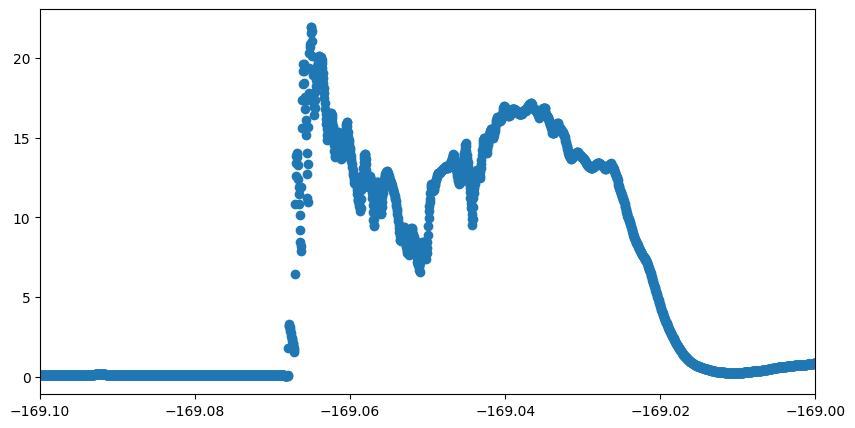

In [9]:
import matplotlib

plt.figure(figsize=(10, 5))
plt.scatter(lons, data)
plt.gca().set_xlim([-169.1, -169.0])

plt.show()

### Example using XY to access Model

In [ ]:
#%load_ext autoreload
#%autoreload 2

from ocean_model_interfaces import GeodeticGridParameters, GeodeticGrid, CoordinateType
import numpy as np
import matplotlib.pyplot as plt
from auv_utility import position_util as position_util

parameters = GeodeticGridParameters("/Users/branch/projs/ocean_worlds/misc_data/models/regularized_vailuluu_plume_24hr_set1/", depthChunkSize=35, latChunkSize=500, lonChunkSize=500)

model = GeodeticGrid(parameters)
model.set_coordinate_type(CoordinateType.XY)
model.set_origin(-169.065, -14.215)

time = 2510816.0
depth = -600

x_extent = [-4000,4000]
y_extent = [-4000,4000]
num_x = 100
num_y = 100
x_meters = np.linspace(x_extent[0], x_extent[1], num_x)
y_meters = np.linspace(y_extent[0], y_extent[1], num_y)

data = np.empty((num_x,num_y))
data[:] = np.nan

for i, y in enumerate(y_meters):
    for j, x in enumerate(x_meters):
        
        model_data = model.get_data(x, y, depth, time)
        data[i,j] = model_data["dye"]

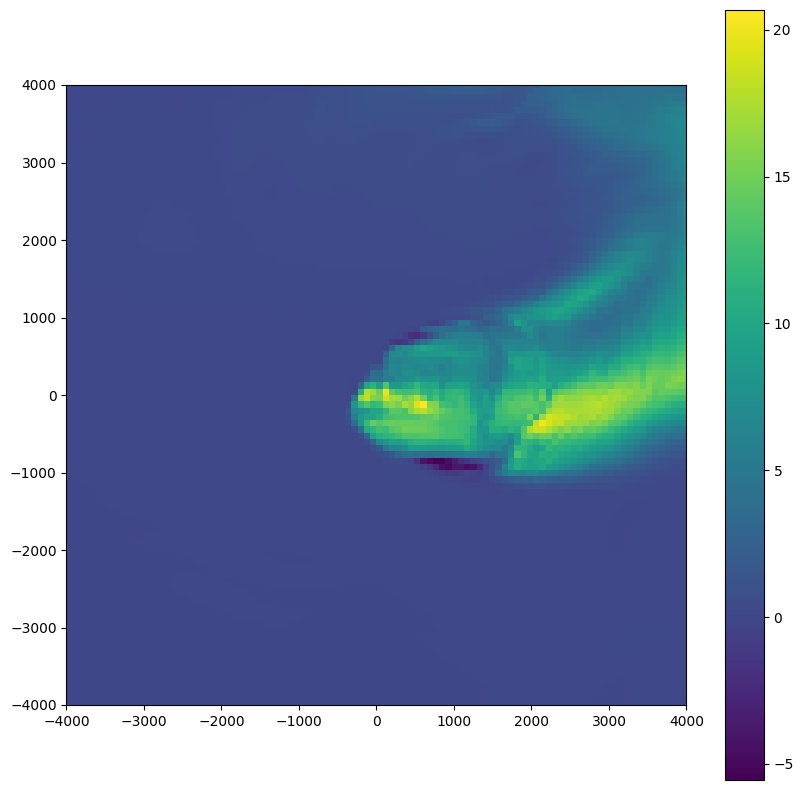

In [ ]:
plt.figure(figsize=(10, 10))
c = plt.gca().pcolormesh(x_meters, y_meters, data, shading="nearest")

plt.colorbar(c)

plt.gca().set_ylim([y_extent[0], y_extent[1]])
plt.gca().set_xlim([x_extent[0], x_extent[1]])

plt.gca().set_aspect('equal')

plt.show()